# Profiling and optimising code

Pure Python can be rather slow. There are many ways to speed it up - first and foremost by making use of array computation through NumPy.

But it can often get even faster, using tools like [Numba](https://numba.pydata.org), [numexpr](https://numexpr.readthedocs.io/en/latest/user_guide.html), [JAX](https://docs.jax.dev/en/latest/index.html), [PyPy](https://doc.pypy.org/en/latest/index.html), and [Cython](https://cython.readthedocs.io/en/latest/src/quickstart/cythonize.html) or by parallelizing computations using e.g. the built-in [multiprocessing](https://docs.python.org/3/library/multiprocessing.html). These can be challenging to use and may not be compatible with your existing code, so only use them when optimisation is really crucial.

Before trying to optimise run times, it's a good idea to know where the bottlenecks are. That's why you'll want to profile your code. This can by done in a notebook with the %timeit, %prun and %lprun (via an extension) magic functions. For .py files, you can run equivalent scripts from the command-line.

In [6]:
from math import sqrt
import numpy as np
import numexpr as ne
from numba import njit
from functools import lru_cache
from functools import wraps
import jax.numpy as jnp
import multiprocessing
%load_ext line_profiler

In [7]:
np.set_printoptions(precision=3, suppress=True)

In this example, we'll calculate the norm of a million 3D vectors in eight different ways:

In [8]:
rng = np.random.default_rng()
A = rng.standard_normal((1000_000, 3))
Ajax = jnp.array(A)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [9]:
def norm1():
    """Pure Python"""
    return [sqrt(a[0]**2 + a[1]**2 + a[2]**2) for a in A]

def norm2():
    """Simple NumPy using np.sum"""
    return np.sqrt(np.sum(A**2, axis=1))

def norm3():
    """np.linalg.norm"""
    return np.linalg.norm(A, axis=1)

@njit
def norm4():
    """Numba on pure Python"""
    return [np.sqrt(a[0]**2 + a[1]**2 + a[2]**2) for a in A]

@njit
def norm5():
    """Numba on simple NumPy"""
    return np.sqrt(np.sum(A**2, axis=1))

@njit
def norm6():
    """Numba on NumPy with 'manual' sum of coordinates"""
    A1, A2, A3 = A.T
    return np.sqrt(A1**2 + A2**2 + A3**2)
    
def norm7():
    """numexpr on simple NumPy (but np.sqrt external since sum must be evaluated last)"""
    return np.sqrt(ne.evaluate('sum(A**2, axis=1)'))

def norm8():
    """numexpr on NumPy with 'manual' sum of coordinates"""
    A1, A2, A3 = A.T
    return ne.evaluate('sqrt(A1**2 + A2**2 + A3**2)')

def norm9():
    """JAX numpy jnp.sum"""
    return jnp.sqrt(jnp.sum(Ajax**2, axis=1))

def norm10():
    """JAX jnp.linalg.norm"""
    return jnp.linalg.norm(Ajax, axis=1)

def _norm(a):
    return np.linalg.norm(a, axis=1)

def norm11():
    """multiprocessing parallelization"""
    split_A = [A[i*200_000:(i+1)*200_000] for i in range(5)]
    with multiprocessing.Pool(5) as pool:
        return np.ravel(pool.map(_norm, split_A))

In [10]:
funcs = [eval(f'norm{i}') for i in range(1,12)]

In [11]:
for func in funcs:
    print(func.__name__, ':', func.__doc__)
    print('Matches reference function output? ', np.allclose(norm1(), func()))
    %timeit func()
    print('-'*70)

norm1 : Pure Python
Matches reference function output?  True
894 ms ± 119 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
----------------------------------------------------------------------
norm2 : Simple NumPy using np.sum
Matches reference function output?  True
25.1 ms ± 1.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
----------------------------------------------------------------------
norm3 : np.linalg.norm
Matches reference function output?  True
25.9 ms ± 2.01 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
----------------------------------------------------------------------
norm4 : Numba on pure Python
Matches reference function output?  True
37.7 ms ± 4.42 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
----------------------------------------------------------------------
norm5 : Numba on simple NumPy
Matches reference function output?  True
12.3 ms ± 1.16 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
------------------------

/home/jsne/.local/share/uv/python/cpython-3.13.2-linux-x86_64-gnu/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Matches reference function output?  True
172 ms ± 27 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
----------------------------------------------------------------------


Caching results can sometimes speed calculations up dramatically - there's no need to calculate the same function with the same arguments more than once, but that can easily happen. Demo of `lru_cache` which can speed up functions that are called repeatedly significantly, although it doesn't work with NumPy arrays.

Taken from https://www.geeksforgeeks.org/python-functools-lru_cache/.

In [12]:
def fib_without_cache(n): 
    if n < 2: 
        return n 
    return fib_without_cache(n-1) + fib_without_cache(n-2) 
      
%timeit fib_without_cache(30);

@lru_cache 
def fib_with_cache(n): 
    if n < 2: 
        return n 
    return fib_with_cache(n-1) + fib_with_cache(n-2) 
      
%timeit fib_with_cache(30);

100 ms ± 15.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
41.7 ns ± 5.68 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


One reason for the massive (~1 million times) speed-up is that %timeit calls the same function multiple times. The first time is therefore significantly slower than the following times. For a more fair comparison, %time runs it only once – but there's still a significant speed-up of around 4 orders of magnitude:

In [13]:
%time fib_without_cache(30);

CPU times: user 171 ms, sys: 1.08 ms, total: 172 ms
Wall time: 171 ms


In [14]:
%time fib_with_cache(30);

CPU times: user 7 μs, sys: 0 ns, total: 7 μs
Wall time: 10.3 μs


Unfortunately, `lru_cache` does not work with NumPy arrays (technical reason: the parameters of the function wrapped by `lru_cache` are used as dictionary keys, and immutable objects like ndarrays cannot be used as dictionary keys). 

The following possible solution with a helper function for making arrays hashable is straight from ChatGPT:

In [15]:
from functools import lru_cache
from numpy.typing import NDArray
import hashlib

class HashableArray:
    """Immutable, hashable view of a NumPy array for caching.

    - Zero-copy hashing if input is C-contiguous.
    - Falls back to a contiguous copy otherwise.
    - Enforces read-only to keep the cache safe.
    """
    __slots__ = ("arr", "_hash")

    def __init__(self, arr: np.ndarray):
        # Prefer zero-copy; copy only if needed
        if not arr.flags.c_contiguous:
            arr = np.ascontiguousarray(arr)  # copy only in the rare non-contiguous case
        # Make a read-only view to prevent accidental mutation
        arr = arr.view()
        arr.setflags(write=False)
        self.arr = arr
        self._hash = None  # lazy compute

    def __hash__(self):
        if self._hash is None:
            # Hash shape + dtype + raw bytes without creating a bytes object
            h = hashlib.blake2b(digest_size=16)
            h.update(str(self.arr.shape).encode())
            h.update(self.arr.dtype.str.encode())
            # memoryview avoids allocating a copy of the data
            h.update(memoryview(self.arr))
            # Combine with shape/dtype to avoid rare hash collisions
            self._hash = hash((self.arr.shape, self.arr.dtype.str, h.digest()))
        return self._hash

    def __eq__(self, other):
        if not isinstance(other, HashableArray):
            return NotImplemented
        # Fast checks first
        if self.arr.shape != other.arr.shape or self.arr.dtype != other.arr.dtype:
            return False
        # Content equality
        return np.array_equal(self.arr, other.arr)


# Example use with lru_cache
@lru_cache(maxsize=512)
def expensive_fn(x: HashableArray, y: HashableArray):
    a, b = x.arr, y.arr
    # ... heavy computation ...
    return (a @ b.T).sum()  # just an example

# Without cache
def expensive_fn_pure(a: NDArray, b: NDArray):
    # ... heavy computation ...
    return (a @ b.T).sum()  # just an example

In [16]:
A = np.random.rand(2000, 64)
B = A[:, ::-1]          # non-contiguous view (will copy once on wrap)
C = np.random.rand(2000, 64)

res1 = expensive_fn(HashableArray(A), HashableArray(C))
res2 = expensive_fn(HashableArray(A), HashableArray(C))  # cache hit
res3 = expensive_fn(HashableArray(B), HashableArray(C))  # B copied once on first wrap

In [17]:
np.allclose(expensive_fn_pure(A, C), expensive_fn(HashableArray(A), HashableArray(C)))

True

The "expensive function" doesn't inherently benefit from the caching, but when run through %timeit we see that the caching with hashing actually works:

In [18]:
%timeit expensive_fn_pure(A, C)
%timeit expensive_fn(HashableArray(A), HashableArray(C))

19.2 ms ± 1.24 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
3.47 ms ± 568 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Profiling and refactoring

Now we'll try to program a tiny 1-qubit circuit consisting of one $R_x(\phi)$ gate followed by an $R_z(\phi)$ gate. We will then calculate the outputs of that for many pairs of $(\phi,\theta)$ values.

The [definition](https://omni.wikiwand.com/en/articles/List_of_quantum_logic_gates#Rotation_operator_gates) of the two gates: 

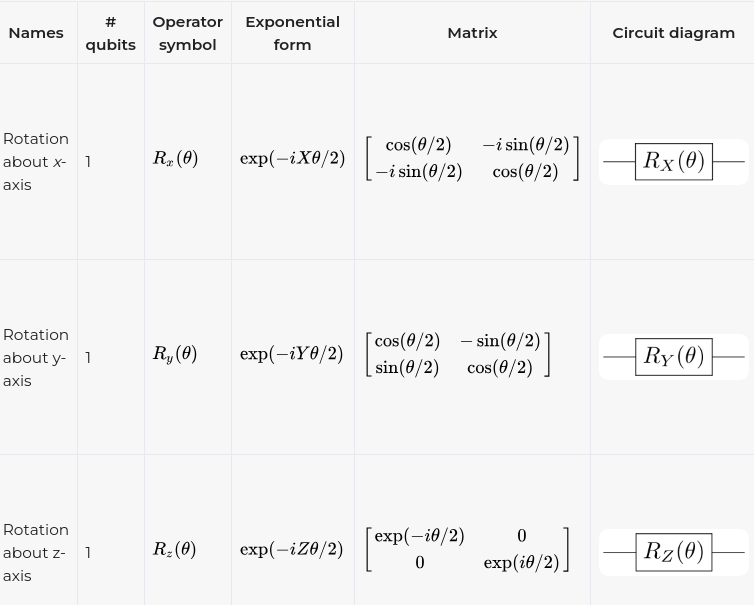

In [19]:
from scipy.linalg import expm

X = np.array([[0,1], [1,0]])
Z = np.array([[1,0], [0,-1]])

def RX(phi):
    out = expm(-1j * phi/2 * X)
    return out

def RZ(phi):
    out = expm(-1j * phi/2 * Z)
    return out

def circuit(phi, theta):
    ket0 = np.array([1,0])
    U = RZ(theta) @ RX(phi)
    out = U @ ket0
    return out

In [20]:
circuit(np.pi/4, np.pi/4)

array([0.854-0.354j, 0.146-0.354j])

We build arrays of phi and theta values using `meshgrid`, but find that our `circuit` function is not compatible with array inputs out of the box:

In [21]:
phis = np.linspace(0, 2*np.pi, 100)
thetas = np.linspace(0, 2*np.pi, 200)
P, T = np.meshgrid(phis, thetas, indexing='xy')
print(phis.shape, thetas.shape, P.shape, T.shape)

(100,) (200,) (200, 100) (200, 100)


In [22]:
circuit(phis, thetas)

ValueError: operands could not be broadcast together with shapes (200,) (2,2) 

In [23]:
circuit(P, T)

ValueError: operands could not be broadcast together with shapes (200,100) (2,2) 

The broadcasting doesn't work, as explained in the error message. This can be fixed by adding two dimensions to our phase arrays:

In [25]:
phis = np.linspace(0, 2*np.pi, 100)
thetas = np.linspace(0, 2*np.pi, 200)
P, T = np.meshgrid(phis, thetas, indexing='xy')

print(phis.shape)
print(P.shape)

phis = phis[..., None, None]
thetas = thetas[..., None, None]
T = T[..., None, None]
P = P[..., None, None]

print(phis.shape)
print(P.shape)

out = circuit(P, T)
print(out.shape)

(100,)
(200, 100)
(100, 1, 1)
(200, 100, 1, 1)
(200, 100, 2)


Now let's profile our code:

In [26]:
%timeit circuit(P, T)

78.3 ms ± 3.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [27]:
%lprun -f circuit circuit(P, T)

Timer unit: 1e-09 s

Total time: 0.129983 s
File: /tmp/ipykernel_192801/1859165869.py
Function: circuit at line 14

Line #      Hits         Time  Per Hit   % Time  Line Contents
    14                                           def circuit(phi, theta):
    15         1      32525.0  32525.0      0.0      ket0 = np.array([1,0])
    16         1  128199924.0 1.28e+08     98.6      U = RZ(theta) @ RX(phi)
    17         1    1746587.0 1.75e+06      1.3      out = U @ ket0
    18         1       3926.0   3926.0      0.0      return out

In [28]:
%lprun -f RZ circuit(P, T)

Timer unit: 1e-09 s

Total time: 0.00379926 s
File: /tmp/ipykernel_192801/1859165869.py
Function: RZ at line 10

Line #      Hits         Time  Per Hit   % Time  Line Contents
    10                                           def RZ(phi):
    11         1    3798368.0  3.8e+06    100.0      out = expm(-1j * phi/2 * Z)
    12         1        895.0    895.0      0.0      return out

In [29]:
%lprun -f expm circuit(P, T) 

Timer unit: 1e-09 s

Total time: 0.108898 s
File: /home/jsne/src/sciqis/.venv/lib/python3.13/site-packages/scipy/linalg/_matfuncs.py
Function: expm at line 210

Line #      Hits         Time  Per Hit   % Time  Line Contents
   210                                           def expm(A):
   211                                               """Compute the matrix exponential of an array.
   212                                           
   213                                               Array argument(s) of this function may have additional
   214                                               "batch" dimensions prepended to the core shape. In this case, the array is treated
   215                                               as a batch of lower-dimensional slices; see :ref:`linalg_batch` for details.
   216                                           
   217                                               Parameters
   218                                               ----------
   219      

We don't learn so much here, except that the line doing both array multiplication (`phi/2 * Z`) and matrix exponentiation (`expm`) takes almost all the time – not surprisingly.

Let's just try to split the two operations to clarify which is heavier:

In [30]:
def RX(phi):
    phiX = phi * X
    out = expm(-1j * phiX / 2)
    return out

def RZ(phi):
    phiZ = phi * Z
    out = expm(-1j * phiZ / 2)
    return out

%lprun -f RZ circuit(P, T)

Timer unit: 1e-09 s

Total time: 0.0112213 s
File: /tmp/ipykernel_192801/2909849057.py
Function: RZ at line 6

Line #      Hits         Time  Per Hit   % Time  Line Contents
     6                                           def RZ(phi):
     7         1    6125376.0 6.13e+06     54.6      phiZ = phi * Z
     8         1    5094284.0 5.09e+06     45.4      out = expm(-1j * phiZ / 2)
     9         1       1673.0   1673.0      0.0      return out

Similarly, we can refactor `circuit` to clarify a bit where time is spent:

In [31]:
def circuit(phi, theta):
    ket0 = np.array([1,0])
    rz = RZ(theta)
    rx = RX(phi)
    U = rx @ rz
    out = U @ ket0
    return out

%lprun -f circuit circuit(P, T)

Timer unit: 1e-09 s

Total time: 0.110284 s
File: /tmp/ipykernel_192801/1262799392.py
Function: circuit at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def circuit(phi, theta):
     2         1      36328.0  36328.0      0.0      ket0 = np.array([1,0])
     3         1    4634482.0 4.63e+06      4.2      rz = RZ(theta)
     4         1  101898225.0 1.02e+08     92.4      rx = RX(phi)
     5         1    2217172.0 2.22e+06      2.0      U = rx @ rz
     6         1    1493435.0 1.49e+06      1.4      out = U @ ket0
     7         1       4550.0   4550.0      0.0      return out

I realise that it may be inefficient to calculate `RZ` and `RX` on the meshgrids `P` and `T`. Since they are functions of only one parameter (not of both phi and theta), each function is actually called 100 or 200 times with identical input parameters. That's a massive waste!

Let's instead try to use only the 1D `phis` and `thetas` arrays as inputs. This can be done by clever use of `einsum` (probably also in different ways): 

In [32]:
RZRX1 = RZ(T) @ RX(P)
RZRX2 = np.einsum('ikl,jlm', RZ(thetas), RX(phis))

In [33]:
np.allclose(RZRX1, RZRX2)

True

In [34]:
def circuit2(phi, theta):
    ket0 = np.array([1,0])
    U = np.einsum('ikl,jlm', RZ(theta), RX(phi))
    out = U @ ket0
    return out

In [35]:
out2 = circuit2(phis, thetas)

In [36]:
out2.shape

(200, 100, 2)

In [37]:
np.allclose(out, out2)

True

In [38]:
%timeit circuit(P, T)
%timeit circuit2(phis, thetas)

79.5 ms ± 3.53 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
6.08 ms ± 96.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


We get roughly a factor 100 speed-up, as expected.

### Refactoring

Using the gate definition in terms of matrix elements instead of the operator exponential might be faster. Let's check.

In [39]:
def RX2(phi):
    phi = np.atleast_1d(phi)
    out = np.array([[np.cos(phi/2), -1j*np.sin(phi/2)], [-1j*np.sin(phi/2), np.cos(phi/2)]])
    out = np.transpose(out, (2,0,1))  # needed because the output dim of the above is (2,2,N)
    return out

def RZ2(phi):
    phi = np.atleast_1d(phi)
    zero = np.zeros(phi.shape)  # needed because the zero entry to the overall matrix should be as long as phi
    out = np.array([[np.exp(-1j*phi/2), zero], [zero, np.exp(1j*phi/2)]])
    out = np.transpose(out, (2,0,1))
    return out

def circuit3(phi, theta):
    ket0 = np.array([1,0])
    U = np.einsum('ikl,jlm', RZ2(theta), RX2(phi))
    out = U @ ket0
    return out

In [40]:
phis_flat = np.linspace(0, 2*np.pi, 100)
thetas_flat = np.linspace(0, 2*np.pi, 200)

np.allclose(RX2(phis_flat), RX(phis)), np.allclose(RZ2(phis_flat), RZ(phis))

(True, True)

In [41]:
np.allclose(circuit3(phis_flat, thetas_flat), circuit2(phis, thetas))

True

In [42]:
%timeit circuit(P, T)
%timeit circuit2(phis, thetas)
%timeit circuit3(phis_flat, thetas_flat)

75.7 ms ± 9.77 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
6.55 ms ± 416 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
854 μs ± 14.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In conclusion:

- A 50–100 times speed-up by using `einsum` on 1D phase arrays instead of `matmul` / `@` on 2D meshgrids.
- A further ~6 times speed-up by using a different (more explicit) mathematical formula for the gate operators.

### Profiling of larger code

For a more realistic example, let's look at simulating the ladder ansatz circuit with a variable number of qubits and layers:

![Ladder ansatz circuit](../exercises/attachments/ladder_ansatz_3_qubits.png)

I will be using ~~my own~~ Claude's [qcircsim](https://github.com/neago/sciqis-qcircsim-claude) simulator. 

In [2]:
from qcircsim import QuantumCircuit, expectation
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

Here I define the circuit with a variable number of qubits (circuit width) and layers (circuit depth):

In [4]:
def run_ansatz(qubits, layers, theta, print_circuit=False):
    qc = QuantumCircuit(qubits)
    for _ in range(layers):
        for q in range(qubits):
            qc.ry(theta, q)
        for q in range(qubits-1):
            qc.cx(q, q+1)

    if print_circuit:
        print(qc)

    state = qc.statevector()

    operator = 'Z'
    return expectation(state, operator * state.num_qubits)
    

# thetas = np.linspace(0, 2*np.pi, 180, endpoint=False)


Let's start by looking into the run time. I could run it over a range of thetas, but that probably won't tell us much (I'd expect the runtime to be mostly proportional to the number of theta values), so we just fix it at 0. 

The %prun magic function - profile run - is sometimes useful, but not here. There are too many sub-sub-sub-function calls:

In [60]:
%prun run_ansatz(10, 10, 0)

         32969 function calls (32963 primitive calls) in 0.037 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      281    0.006    0.000    0.013    0.000 numeric.py:2384(isclose)
      200    0.003    0.000    0.005    0.000 numeric.py:1001(tensordot)
      280    0.003    0.000    0.020    0.000 gates.py:34(__init__)
      842    0.002    0.000    0.002    0.000 {method 'reduce' of 'numpy.ufunc' objects}
      842    0.001    0.000    0.005    0.000 fromnumeric.py:86(_wrapreduction_any_all)
       90    0.001    0.000    0.029    0.000 circuit.py:164(cx)
      370    0.001    0.000    0.002    0.000 _twodim_base_impl.py:176(eye)
      400    0.001    0.000    0.002    0.000 numeric.py:1431(normalize_axis_tuple)
      801    0.001    0.000    0.001    0.000 {method 'reshape' of 'numpy.ndarray' objects}
      190    0.001    0.000    0.001    0.000 circuit.py:53(append)
      800    0.001    0.000    0.001    0.000 {built

%lprun, the line profiler, is much more informative:

In [61]:
%lprun -f run_ansatz run_ansatz(5, 5, 0)

Timer unit: 1e-09 s

Total time: 0.013934 s
File: /tmp/ipykernel_159237/277189142.py
Function: run_ansatz at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def run_ansatz(qubits, layers, theta, print_circuit=False):
     2         1       7342.0   7342.0      0.1      qc = QuantumCircuit(qubits)
     3         6       3674.0    612.3      0.0      for _ in range(layers):
     4        30      17111.0    570.4      0.1          for q in range(qubits):
     5        25    4071206.0 162848.2     29.2              qc.ry(theta, q)
     6        25      13802.0    552.1      0.1          for q in range(qubits-1):
     7        20    3830168.0 191508.4     27.5              qc.cx(q, q+1)
     8                                           
     9         1        436.0    436.0      0.0      if print_circuit:
    10                                                   print(qc)
    11                                           

We see that there are three lines that spend most of the time: The addition of the Ry and CNOT gates to the circuit, and the calculation of the final statevector. I'm curious why it takes time to add a gate - that shouldn't really take much time, since I don't think it immediately multiplies the matrices. Let's dig deeper. To do that, we first need to import the full library and profile (with `-f`) e.g. the `cx` method of the `QuantumCircuit` class which `qc` is an instance of:

In [62]:
import qcircsim

In [63]:
%lprun -f QuantumCircuit.cx run_ansatz(5, 5, 0)

Timer unit: 1e-09 s

Total time: 0.0060029 s
File: /home/jsne/src/sciqis/.venv/lib/python3.13/site-packages/qcircsim/circuit.py
Function: QuantumCircuit.cx at line 164

Line #      Hits         Time  Per Hit   % Time  Line Contents
   164                                               def cx(self, control, target, condition=None):
   165                                                   """Controlled-X (CNOT)."""
   166        20    6002902.0 300145.1    100.0          return self.append(_g.cx(), [control, target], condition)

Okay, we have to go deeper. By inspecting the code, I find that `_g` is a shorthand for the `qcircsim.cx` module, so we go to...

In [64]:
%lprun -f qcircsim.gates.cx run_ansatz(5, 5, 0)

Timer unit: 1e-09 s

Total time: 0.00396054 s
File: /home/jsne/src/sciqis/.venv/lib/python3.13/site-packages/qcircsim/gates.py
Function: cx at line 212

Line #      Hits         Time  Per Hit   % Time  Line Contents
   212                                           def cx():
   213                                               """Controlled-X (CNOT); control is the first qubit."""
   214        20    3960540.0 198027.0    100.0      return x().control(name="cx")

100%...

Two functions are called here - the `x()` function of the `gates` module and the `control()` method of the `Gate` class. Let's look at both:

In [66]:
%lprun -f qcircsim.gates.x run_ansatz(5, 5, 0)

Timer unit: 1e-09 s

Total time: 0.00200267 s
File: /home/jsne/src/sciqis/.venv/lib/python3.13/site-packages/qcircsim/gates.py
Function: x at line 134

Line #      Hits         Time  Per Hit   % Time  Line Contents
   134                                           def x():
   135                                               """Pauli-X (NOT) gate."""
   136        20    2002667.0 100133.4    100.0      return Gate("x", 1, _X)

In [67]:
%lprun -f qcircsim.gates.Gate.control run_ansatz(5, 5, 0)

Timer unit: 1e-09 s

Total time: 0.00201909 s
File: /home/jsne/src/sciqis/.venv/lib/python3.13/site-packages/qcircsim/gates.py
Function: Gate.control at line 63

Line #      Hits         Time  Per Hit   % Time  Line Contents
    63                                               def control(self, num_controls=1, name=None):
    64                                                   """Return the controlled version of this gate.
    65                                           
    66                                                   The control qubits come first in the qubit list of the resulting
    67                                                   gate; the gate acts on the remaining qubits when all controls are 1.
    68                                                   """
    69        20      12504.0    625.2      0.6          if num_controls < 1:
    70                                                       raise ValueError("num_controls must be >= 1")
    71        20      10484.

Both of these are spending most time on instantiating a `Gate` object. Let's look at that class's initializer:

In [68]:
%lprun -f qcircsim.gates.Gate.__init__ run_ansatz(5, 5, 0)

Timer unit: 1e-09 s

Total time: 0.00923276 s
File: /home/jsne/src/sciqis/.venv/lib/python3.13/site-packages/qcircsim/gates.py
Function: Gate.__init__ at line 34

Line #      Hits         Time  Per Hit   % Time  Line Contents
    34                                               def __init__(self, name, num_qubits, matrix, params=()):
    35        65     186404.0   2867.8      2.0          matrix = np.array(matrix, dtype=complex)
    36        65      37851.0    582.3      0.4          dim = 2**num_qubits
    37        65      54217.0    834.1      0.6          if matrix.shape != (dim, dim):
    38                                                       raise ValueError(
    39                                                           f"gate '{name}' on {num_qubits} qubit(s) needs a {dim}x{dim} "
    40                                                           f"matrix, got {matrix.shape}"
    41                                                       )
    42        65    8549827.0 131535

AHA! When instantiating a gate, the gate's matrix representation is passed as an argument. And 90% of the time of the instantiating is spent on checking whether this matrix is unitary which involves a relatively heavy matrix multiplication. That's a massive waste of time! If the matrix is user-suppled, it for sure makes sense to check for unitarity. When, like here, the gates are predefined within the package itself - and furthermore, the same gates is called hundreds of times - it's insane to perform this check. That's an obvious place to try to optimize the code (and it shows that even Claude Fable can create silly code).

Finally, we will look at the runtime of the code from a more quantum information related perspective. How does the runtime scale with the width (number of qubits) and depth (number of layers) of the circuit?

Running the code below takes several minutes, but the plot is set to update along the way, for each added qubit/layer.

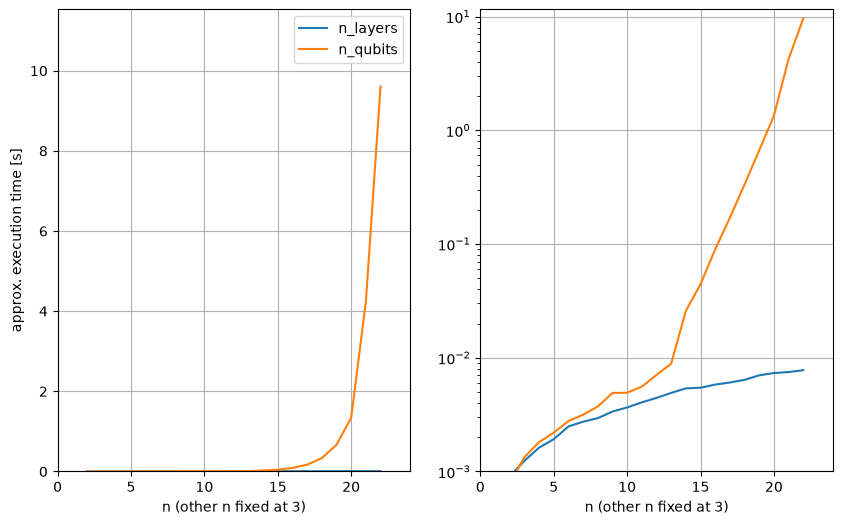

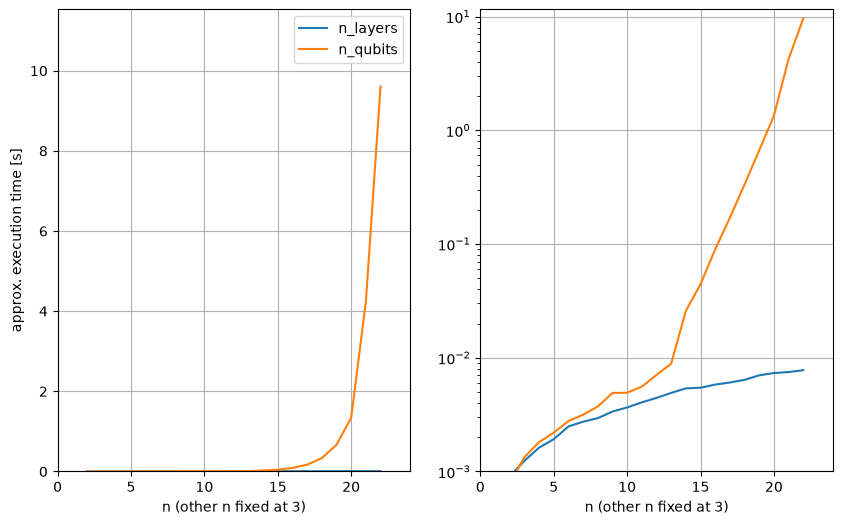

In [5]:
times_nl = []
times_nq = []
nl_fixed = 3
nq_fixed = 3
nmax=23
# timeit_r = 5

frames = []

fig, ax = plt.subplots(1, 2, figsize=(10,6))

for n in range(2, nmax):
    tl = %timeit -o -r 5 run_ansatz(nq_fixed, n, theta=0)
    tq = %timeit -o -r 5 run_ansatz(n, nl_fixed, theta=0)
    times_nl.append(tl)
    times_nq.append(tq)
    frames.append((times_nl.copy(), times_nq.copy()))
    max_time = max(max([t.average for t in times_nl]), 
                   max([t.average for t in times_nq]))

    ax[0].clear()
    ax[1].clear()

    ax[0].plot(range(2, n+1), [t.average for t in times_nl], label='n_layers')
    ax[0].plot(range(2, n+1), [t.average for t in times_nq], label='n_qubits')
    ax[0].grid()
    ax[0].legend()
    ax[0].set_xlim(0, nmax+1)
    ax[0].set_ylim(0, 1.2 * max_time)
    ax[0].set_ylabel('approx. execution time [s]')
    ax[0].set_xlabel('n (other n fixed at 3)')

    ax[1].semilogy(range(2, n+1), [t.average for t in times_nl], label='n_layers')
    ax[1].semilogy(range(2, n+1), [t.average for t in times_nq], label='n_qubits')
    ax[1].grid()
    ax[1].set_xlim(0, nmax+1)
    ax[1].set_ylim(.001, 1.2 * max_time)
    ax[1].set_xlabel('n (other n fixed at 3)')

    clear_output(wait=True)
    display(fig)